<a href="https://colab.research.google.com/github/utkarsh-mishra19/Tensorflow_projects/blob/main/Malaria_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, InputLayer, BatchNormalization
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import RootMeanSquaredError

In [2]:
dataset, data_info = tfds.load('malaria',with_info=True, split=['train'], as_supervised=True, shuffle_files=True)

In [3]:
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1
def dsplit(dataset, train_ratio, val_ratio, test_ratio):
    train_size = int(len(dataset) * train_ratio)
    val_size = int(len(dataset) * val_ratio)
    test_size = int(len(dataset) * test_ratio)

    train_dataset = dataset.take(train_size)
    val_dataset = dataset.skip(train_size).take(val_size)
    test_dataset = dataset.skip(train_size + val_size).take(test_size)

    return train_dataset, val_dataset, test_dataset

In [4]:
train_data,val_data,test_data= dsplit(dataset[0],train_ratio,val_ratio,test_ratio)


Data Visualization

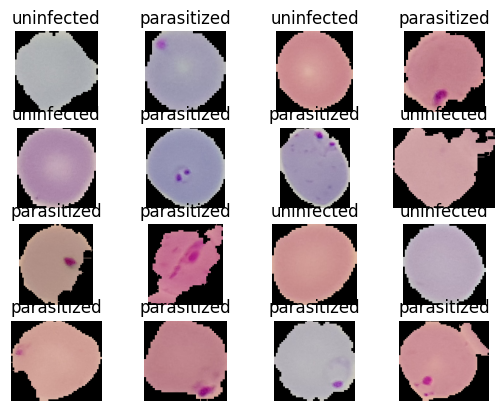

In [5]:
for i,(image,label) in enumerate(train_data.take(16)):
    plt.subplot(4,4,i+1)
    plt.imshow(image)
    plt.title(data_info.features['label'].int2str(label))
    plt.axis('off')

Preprocessing data

In [6]:
 def resize_rescale(image,label):
  return tf.image.resize(image,(224,224))/255.0,label

In [7]:
train_data = train_data.map(resize_rescale)
val_data = val_data.map(resize_rescale)
test_data = test_data.map(resize_rescale)

In [8]:
train_data = train_data.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)
val_data = val_data.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)
test_data = test_data.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)


In [13]:
model = tf.keras.Sequential([
    InputLayer(input_shape=(224,224,3)),
    Conv2D(filters=6,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Conv2D(filters=16,kernel_size=3,strides=1,padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=2,strides=2),
    Flatten(),
    Dense(units=120,activation='relu'),
    BatchNormalization(),
    Dense(units=20,activation='relu'),
    BatchNormalization(),
    Dense(units=1,activation='sigmoid')

])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │     5,598,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 120)            │           480 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │         2,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,602,977 (21.37 MB)

 Trainable params: 5,602,653 (21.37 MB)

 Non-trainable params: 324 (1.27 KB)

In [18]:
model.compile(optimizer= Adam(learning_rate=0.1),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [19]:
model.fit(train_data,validation_data=val_data,epochs=10,verbose=1)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.9132 - loss: 0.2709 - val_accuracy: 0.8639 - val_loss: 0.5116
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 45s 65ms/step - accuracy: 0.9327 - loss: 0.2329 - val_accuracy: 0.6348 - val_loss: 1.5176
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.9292 - loss: 0.2349 - val_accuracy: 0.8555 - val_loss: 0.3672
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 47s 69ms/step - accuracy: 0.9397 - loss: 0.2026 - val_accuracy: 0.9416 - val_loss: 0.1978
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.9466 - loss: 0.1720 - val_accuracy: 0.9401 - val_loss: 0.2424
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.9523 - loss: 0.1480 - val_accuracy: 0.9463 - val_loss: 0.1887
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.9545 - loss: 0.1361 - val_accuracy: 0.9466 - val_loss: 0.1981
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 45s 66ms/step - accuracy: 0.9624 - loss: 0.1194 - 

In [21]:
model.evaluate(test_data)

87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9406 - loss: 0.2609


[0.2687774896621704, 0.9379310607910156]

Predection

In [23]:
model.predict(test_data.take(1))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


np.float32(0.9999883)

If more than 0.5 = normal

If less than 0.5 = infected